# Laboratory work 3

### Dependencies

In [1]:
%matplotlib ipympl

import mujoco
import mujoco.viewer
import time
import itertools
import numpy as np
from numpy import pi, sin, cos
import mediapy as media
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
import enum
from tqdm import tqdm
from scipy.integrate import solve_ivp

import os
os.environ['MUJOCO_GL'] = 'osmesa'
os.environ['__NV_PRIME_RENDER_OFFLOAD'] = '1'
os.environ['__GLX_VENDOR_LIBRARY_NAME'] = 'nvidia'


camera = mujoco.MjvCamera()
camera.type = mujoco.mjtCamera.mjCAMERA_FREE
camera.lookat = [0, 0, 0]
camera.distance = 3.0
camera.azimuth = 90
camera.elevation = 0

frames = []

In [2]:
'''model = mujoco.MjModel.from_xml_path('two_link.xml')
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model, height=480, width=640)

camera = mujoco.MjvCamera()
camera.type = mujoco.mjtCamera.mjCAMERA_FREE
camera.lookat = [0, 0, 0]
camera.distance = 3.0
camera.azimuth = 90
camera.elevation = 0

# Создаем список кадров
frames = []

set_q = np.array([pi/2, pi/2])
max_torque = 1.0

kp = 0.1
error = np.array([0, 0])

data.qpos[0] = 0.0 

for i in range(300):

    for a in range(0, 2):
        error[a] = set_q[a] - data.qpos[a]
        data.ctrl[a] += kp * error[a]

    # data.ctrl[0] = np.clip(kp * error[0], -max_torque, max_torque)
    # data.ctrl[1] = np.clip(kp * error[1], -max_torque, max_torque)

    mujoco.mj_step(model, data)
    
    renderer.update_scene(data, camera=camera)
    frames.append(renderer.render())

    # if i % 30 == 0:
    #     print(data.qpos[0], data.qpos[1])

# Показать анимацию
# media.show_video(frames, fps=30)'''

"model = mujoco.MjModel.from_xml_path('two_link.xml')\ndata = mujoco.MjData(model)\nrenderer = mujoco.Renderer(model, height=480, width=640)\n\ncamera = mujoco.MjvCamera()\ncamera.type = mujoco.mjtCamera.mjCAMERA_FREE\ncamera.lookat = [0, 0, 0]\ncamera.distance = 3.0\ncamera.azimuth = 90\ncamera.elevation = 0\n\n# Создаем список кадров\nframes = []\n\nset_q = np.array([pi/2, pi/2])\nmax_torque = 1.0\n\nkp = 0.1\nerror = np.array([0, 0])\n\ndata.qpos[0] = 0.0 \n\nfor i in range(300):\n\n    for a in range(0, 2):\n        error[a] = set_q[a] - data.qpos[a]\n        data.ctrl[a] += kp * error[a]\n\n    # data.ctrl[0] = np.clip(kp * error[0], -max_torque, max_torque)\n    # data.ctrl[1] = np.clip(kp * error[1], -max_torque, max_torque)\n\n    mujoco.mj_step(model, data)\n    \n    renderer.update_scene(data, camera=camera)\n    frames.append(renderer.render())\n\n    # if i % 30 == 0:\n    #     print(data.qpos[0], data.qpos[1])\n\n# Показать анимацию\n# media.show_video(frames, fps=30)"

### Forward Dynamcis

This browser does not support the video tag.


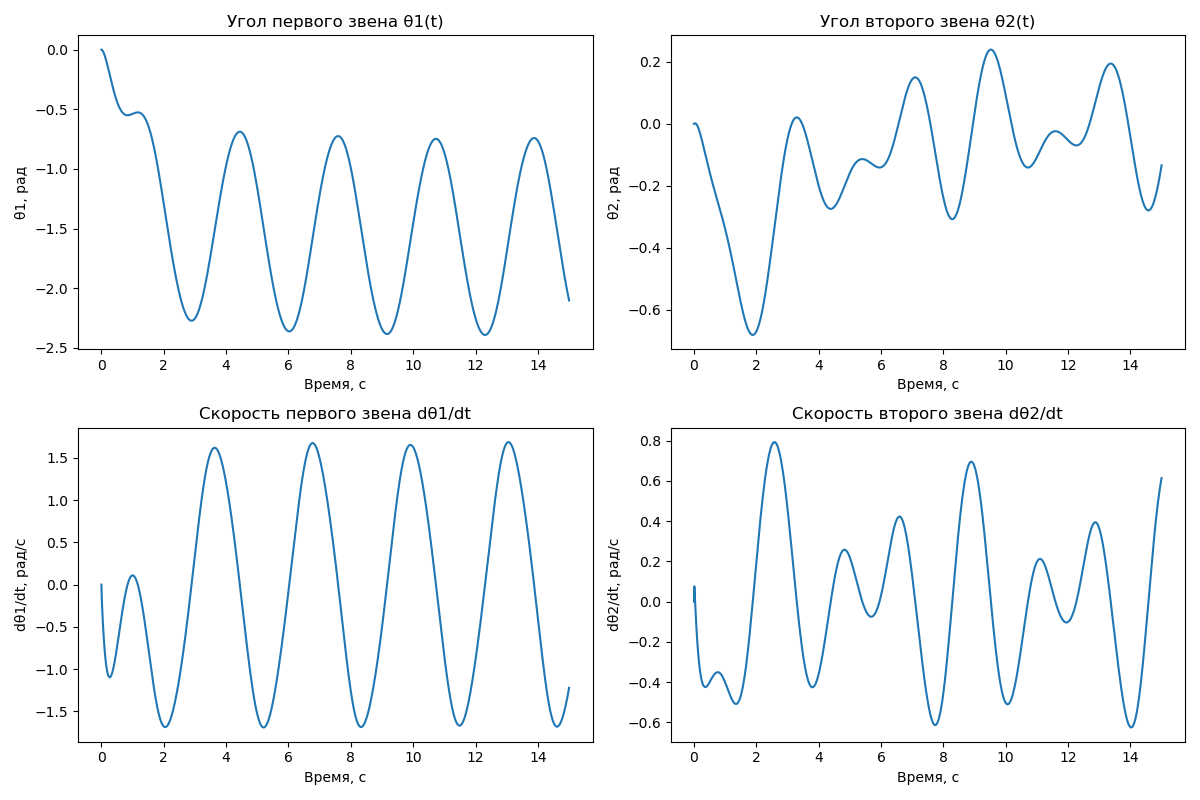

In [ ]:
m1, m2 = 1.5, 1.5
a1, a2 = 0.5, 0.5
b1, b2 = 10.0, 10.0
g = 9.81

def manipulator_dynamics(t, y, tau1, tau2):
    theta1, theta2, dtheta1, dtheta2 = y
    
    # Inertia matrix M(q)
    M11 = (m1 + m2)*a1**2 + m2*a2**2 + 2*m2*a1*a2*np.cos(theta2)
    M12 = m2*a2**2 + m2*a1*a2*np.cos(theta2)
    M21 = M12
    M22 = m2*a2**2
    
    M = np.array([[M11, M12], [M21, M22]])
    
    # Coriolis and centrifugal forces V(q, dq)
    V1 = -m2*a1*a2*(2*dtheta1*dtheta2 + dtheta2**2)*np.sin(theta2)
    V2 = m2*a1*a2*dtheta1**2*np.sin(theta2)
    V = np.array([V1, V2])
    
    # Gravitational forces G(q)
    G1 = (m1 + m2)*g*a1*np.cos(theta1) + m2*g*a2*np.cos(theta1 + theta2)
    G2 = m2*g*a2*np.cos(theta1 + theta2)
    G = np.array([G1, G2])
    
    tau = np.array([tau1(t) - b1*dtheta1, tau2(t) - b2*dtheta2])
    
    rhs = tau - V - G
    ddot_q = np.linalg.solve(M, rhs)
    
    return [dtheta1, dtheta2, ddot_q[0], ddot_q[1]]

def tau1(t):
    return 20 * np.sin(2*t)
    # return 0

def tau2(t): 
    return 4 * np.sin(3*t)
    # return 0

theta1_0, theta2_0 = 0.0, 0.0
dtheta1_0, dtheta2_0 = 0.0, 0.0
y0 = [theta1_0, theta2_0, dtheta1_0, dtheta2_0]

t_span = (0, 15)
t_eval = np.linspace(0, 15, 1000)

# Решение ОДУ
solution = solve_ivp(
    manipulator_dynamics, 
    t_span, 
    y0, 
    args=(tau1, tau2),
    t_eval=t_eval,
    method='RK45'
)


model = mujoco.MjModel.from_xml_path('two_link.xml')
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model, height=480, width=640)

# from scipy.interpolate import interp1d
# theta1_interp = interp1d(solution.t, solution.y[0], kind='cubic')
# theta2_interp = interp1d(solution.t, solution.y[1], kind='cubic')

for i, t in enumerate(np.linspace(0, 15, 450)):  # 30 FPS
    # data.qpos[0] = theta1_interp(t)
    # data.qpos[1] = theta2_interp(t)

    idx = np.argmin(np.abs(solution.t - t))
    data.qpos[0] = solution.y[0, idx]
    # data.qpos[0] = pi/4
    data.qpos[1] = solution.y[1, idx]
    # data.qpos[1] = pi/4

    mujoco.mj_forward(model, data)
    renderer.update_scene(data, camera=camera)
    frames.append(renderer.render())

media.show_video(frames, fps=30)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(solution.t, solution.y[0])
plt.title('Угол первого звена θ1(t)')
plt.xlabel('Время, с')
plt.ylabel('θ1, рад')

plt.subplot(2, 2, 2)
plt.plot(solution.t, solution.y[1])
plt.title('Угол второго звена θ2(t)')
plt.xlabel('Время, с')
plt.ylabel('θ2, рад')

plt.subplot(2, 2, 3)
plt.plot(solution.t, solution.y[2])
plt.title('Скорость первого звена dθ1/dt')
plt.xlabel('Время, с')
plt.ylabel('dθ1/dt, рад/с')

plt.subplot(2, 2, 4)
plt.plot(solution.t, solution.y[3])
plt.title('Скорость второго звена dθ2/dt')
plt.xlabel('Время, с')
plt.ylabel('dθ2/dt, рад/с')

plt.tight_layout()
plt.show()

### Inverse Dynamics

This browser does not support the video tag.


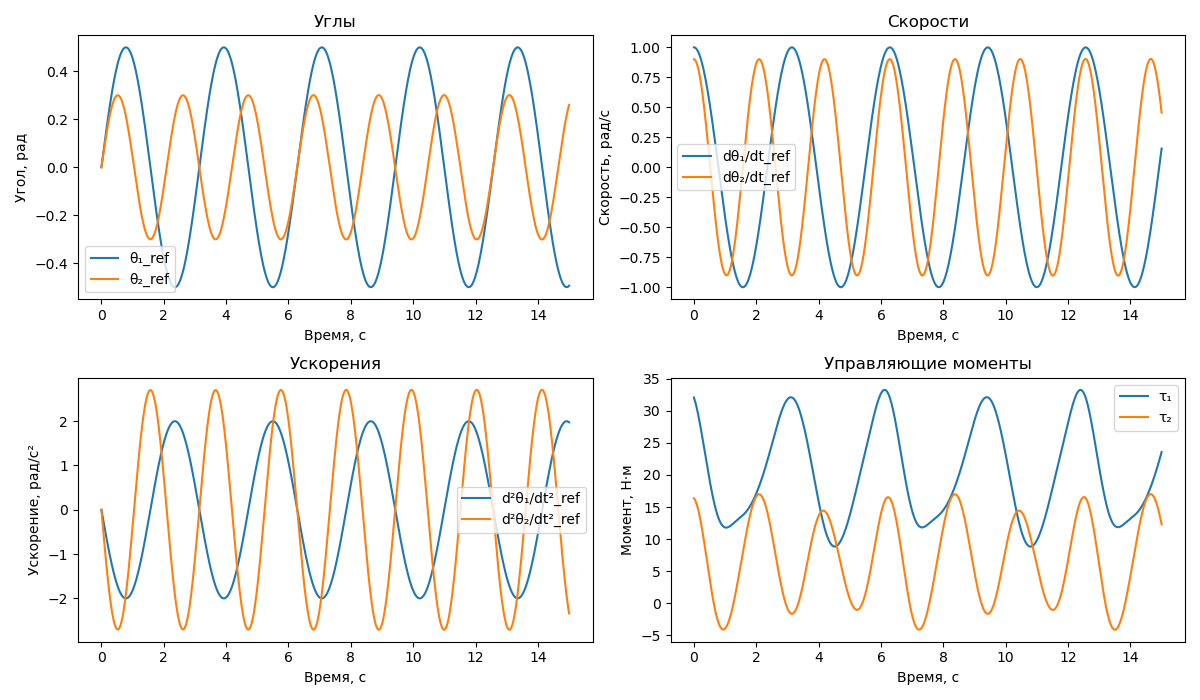

In [4]:
m1, m2 = 1.5, 1.5
a1, a2 = 0.5, 0.5
b1, b2 = 10.0, 10.0
g = 9.81

# freq
omega_ref1 = 2.0
omega_ref2 = 3.0

A_ref1 = 0.5
A_ref2 = 0.3

C_ref1 = 0.0
C_ref2 = 0.0

psi_ref1 = 0.0
psi_ref2 = 0.0

S_ref1 = np.array([[0, 0, 0],
                   [0, 0, 1],
                   [0, -omega_ref1**2, 0]])

S_ref2 = np.array([[0, 0, 0],
                   [0, 0, 1], 
                   [0, -omega_ref2**2, 0]])

S_ref = np.block([[S_ref1, np.zeros((3, 3))],
                  [np.zeros((3, 3)), S_ref2]])

H_ref_p1 = np.array([[1, 1, 0]])
H_ref_p2 = np.array([[1, 1, 0]])
H_ref_p = np.block([[H_ref_p1, np.zeros((1, 3))],
                    [np.zeros((1, 3)), H_ref_p2]])

H_ref_v1 = np.array([[0, 0, 1]])
H_ref_v2 = np.array([[0, 0, 1]])
H_ref_v = np.block([[H_ref_v1, np.zeros((1, 3))],
                    [np.zeros((1, 3)), H_ref_v2]])

H_ref_a1 = np.array([[0, -omega_ref1**2, 0]])
H_ref_a2 = np.array([[0, -omega_ref2**2, 0]])
H_ref_a = np.block([[H_ref_a1, np.zeros((1, 3))],
                    [np.zeros((1, 3)), H_ref_a2]])

w_ref0 = np.array([
    C_ref1,
    A_ref1 * np.sin(psi_ref1),
    omega_ref1 * A_ref1 * np.cos(psi_ref1),
    C_ref2, 
    A_ref2 * np.sin(psi_ref2),
    omega_ref2 * A_ref2 * np.cos(psi_ref2)
])

def trajectory_generator(t, w):
    return S_ref @ w

t_eval = np.linspace(0, 15, 1000)
sol = solve_ivp(trajectory_generator, [0, 15], w_ref0, t_eval=t_eval, method='RK45')

w_ref = sol.y
q_ref = H_ref_p @ w_ref
dq_ref = H_ref_v @ w_ref  
ddq_ref = H_ref_a @ w_ref

def inverse_dynamics(q, dq, ddq):
    theta1, theta2 = q
    dtheta1, dtheta2 = dq
    ddtheta1, ddtheta2 = ddq
    
    M11 = (m1 + m2)*a1**2 + m2*a2**2 + 2*m2*a1*a2*np.cos(theta2)
    M12 = m2*a2**2 + m2*a1*a2*np.cos(theta2)
    M21 = M12
    M22 = m2*a2**2
    M = np.array([[M11, M12], [M21, M22]])
    
    V1 = -m2*a1*a2*(2*dtheta1*dtheta2 + dtheta2**2)*np.sin(theta2)
    V2 = m2*a1*a2*dtheta1**2*np.sin(theta2)
    V = np.array([V1, V2])

    G1 = (m1 + m2)*g*a1*np.cos(theta1) + m2*g*a2*np.cos(theta1 + theta2)
    G2 = m2*g*a2*np.cos(theta1 + theta2)
    G = np.array([G1, G2])

    tau = M @ np.array([ddtheta1, ddtheta2]) + V + G
    
    # add friction
    tau_fr = np.array([
        tau[0] + b1 * dtheta1,
        tau[1] + b2 * dtheta2
    ])
    
    return tau_fr

tau1_ref = np.zeros_like(t_eval)
tau2_ref = np.zeros_like(t_eval)

for i in range(len(t_eval)):
    q = q_ref[:, i]
    dq = dq_ref[:, i]
    ddq = ddq_ref[:, i]
    tau = inverse_dynamics(q, dq, ddq)
    tau1_ref[i] = tau[0]
    tau2_ref[i] = tau[1]


mujoco.mj_resetData(model, data)

frames_inverse = []

for i, t in enumerate(np.linspace(0, 15, 450)):  # 30 FPS
    idx = np.argmin(np.abs(t_eval - t))
    
    data.qpos[0] = q_ref[0, idx]
    data.qpos[1] = q_ref[1, idx]
    
    mujoco.mj_forward(model, data)
    renderer.update_scene(data, camera=camera)
    frames_inverse.append(renderer.render())


media.show_video(frames_inverse, fps=30)


plt.figure(figsize=(12, 7))

plt.subplot(2, 2, 1)
plt.plot(t_eval, q_ref[0], label='θ₁_ref')
plt.plot(t_eval, q_ref[1], label='θ₂_ref')
plt.title('Углы')
plt.xlabel('Время, с')
plt.ylabel('Угол, рад')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(t_eval, dq_ref[0], label='dθ₁/dt_ref')
plt.plot(t_eval, dq_ref[1], label='dθ₂/dt_ref')
plt.title('Скорости')
plt.xlabel('Время, с')
plt.ylabel('Скорость, рад/с')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(t_eval, ddq_ref[0], label='d²θ₁/dt²_ref')
plt.plot(t_eval, ddq_ref[1], label='d²θ₂/dt²_ref')
plt.title('Ускорения')
plt.xlabel('Время, с')
plt.ylabel('Ускорение, рад/с²')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(t_eval, tau1_ref, label='τ₁')
plt.plot(t_eval, tau2_ref, label='τ₂')
plt.title('Управляющие моменты')
plt.xlabel('Время, с')
plt.ylabel('Момент, Н·м')
plt.legend()

plt.tight_layout()
plt.show()